# Fashion Intelligence System

**COSC2753 Machine Learning — Assignment 2 (2026B)**

Sections 1–3 prepare the shared `model_ready` table and image transform for Tasks 1–4. Only `train/` is read; each task creates its own grouped split and all objects remain in memory.

The preprocessing stage deliberately stops before modelling choices such as loss weighting, augmentation, or train-validation allocation. Keeping those choices in the task sections makes their comparisons traceable to the same audited source data.

In [39]:
%matplotlib inline
import csv
import hashlib
import math
import warnings
from collections import Counter
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.colors import LogNorm
from PIL import Image, ImageOps
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)

TARGETS = ["articleType", "season", "gender", "usage"]
REQUIRED_COLUMNS = {
    "id", "gender", "masterCategory", "subCategory", "articleType",
    "baseColour", "season", "year", "usage", "productDisplayName",
}

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#8b6fc0", "#e87ba4"]
MUTED = "#6b7280"


def find_project_root(start):
    for candidate in [start, *start.parents]:
        if (candidate /"datasets" / "train" / "styles_train.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate train/styles_train.csv")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
TRAIN_DIR = PROJECT_ROOT / "datasets" / "train"
TRAIN_CSV = TRAIN_DIR / "styles_train.csv"
TRAIN_IMAGE_DIR = TRAIN_DIR / "images_train"

print("Training CSV available:", TRAIN_CSV.exists())
print("Training image directory available:", TRAIN_IMAGE_DIR.exists())


RANDOM_STATE = 42  # deterministic sampling for every figure below


def show_image_grid(rows, title=None, row_labels=None, scale=1.5):
    """Render a grid of images. `rows` is a list of rows, each a list of (path, caption)."""
    ncols = max(len(row) for row in rows)
    fig, axes = plt.subplots(
        len(rows), ncols,
        figsize=(scale * ncols, scale * 1.5 * len(rows) + 0.5),
        squeeze=False,
    )
    for row_index, row in enumerate(rows):
        for column_index in range(ncols):
            ax = axes[row_index][column_index]
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            for spine in ax.spines.values():
                spine.set_visible(False)
            if column_index < len(row):
                path, caption = row[column_index]
                with Image.open(path) as image:
                    ax.imshow(ImageOps.exif_transpose(image).convert("RGB"))
                if caption:
                    ax.set_title(caption, fontsize=7)

        if row_labels:
            axes[row_index][0].set_ylabel(
                row_labels[row_index], fontsize=8, rotation=0, ha="right", va="center"
            )

    if title:
        fig.suptitle(title, y=1.0, fontsize=11)

    plt.tight_layout();
    plt.show();


def sample_paths(frame, n, seed_offset=0):
    """Deterministically take up to n rows from a frame that has id/path columns."""
    if len(frame) == 0:
        return []
    picked = frame.sample(n=min(n, len(frame)), random_state=RANDOM_STATE + seed_offset)
    return list(picked.itertuples(index=False))

Training CSV available: True
Training image directory available: True


# 1. What data do we actually have?

## 1.1 Does the CSV parse the way we think it does?

The CSV is audited for row width and pandas parsing before labels are used. This confirms whether malformed product names have shifted any target columns.

The goal is not to re-document CSV parsing generally, but to establish that every downstream count and label refers to the intended product record. The raw-width check and cleaned dataframe check provide that evidence.

In [40]:
with TRAIN_CSV.open("r", encoding="utf-8-sig", newline="") as stream:
    csv_rows = list(csv.reader(stream))

raw_df = pd.read_csv(TRAIN_CSV)

print(f"Raw shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
print("Absent required columns:", sorted(REQUIRED_COLUMNS - set(raw_df.columns)))
print("Unexpected columns:", sorted(set(raw_df.columns) - REQUIRED_COLUMNS))

summary = pd.DataFrame({
    "Data Type": raw_df.dtypes,
    "Non-null": raw_df.notna().sum(),
    "Missing": raw_df.isna().sum(),
    "Unique": raw_df.nunique(dropna=True),
})

display(summary)

Raw shape: 38,617 rows x 12 columns
Absent required columns: []
Unexpected columns: ['Unnamed: 10', 'Unnamed: 11']


,Data Type,Non-null,Missing,Unique
id,int64,38617,0,38617
gender,str,38617,0,5
masterCategory,str,38617,0,7
subCategory,str,38617,0,41
articleType,str,38617,0,125
baseColour,str,38603,14,46
season,str,38597,20,4
year,int64,38617,0,12
usage,str,38545,72,8
productDisplayName,str,38610,7,27550


In [23]:
overflow_columns = [c for c in raw_df.columns if str(c).startswith("Unnamed:")]
overflow_mask = raw_df[overflow_columns].notna().any(axis=1)

print("Affected rows:", overflow_mask.sum())

display(
    raw_df.loc[
        overflow_mask,
        ["id", "productDisplayName", *overflow_columns],
    ]
)

Affected rows: 21


,id,productDisplayName,Unnamed: 10,Unnamed: 11
1320,3413,Myntra Men's Yes,its all about me White T-shirt,NaN
1325,3418,Myntra Men's Take my advice,I don't use it anyway Black T-shirt,NaN
1335,3428,Myntra Mens Be Reasonable,Do It My Way T-shirt,NaN
2689,4854,Newfeel Unisex White,Blue and Orange Casual Shoes,NaN
17899,23100,Turtle Men Formal Navy Blue Tie,Cufflink and Pocket Square Combo Set,NaN
17900,23101,Turtle Men Formal Pink Tie,Cufflink and Pocket Square Combo Set,NaN
17902,23103,Turtle Men Formal Black Tie,Cufflink and Pocket Square Combo Set,NaN
17906,23107,Turtle Men Formal Purple Tie,Cufflink and Pocket Square Combo Set,NaN
17907,23108,Turtle Men Formal Purple Tie,Cufflink and Pocket Square Combo Set,NaN
17908,23109,Turtle Men Formal Purple Tie,Cufflink and Pocket Square Combo Set,NaN


Every one of the 38,617 data rows has 12 fields although the header declares 10 columns. Pandas creates `Unnamed: 10` and `Unnamed: 11`; 21 rows populate them because unquoted commas split `productDisplayName`.

The spill occurs only after the last real column, so target labels remain aligned. The affected name fragments can therefore be rejoined without manual label repair.

The affected fields are text fragments rather than additional attributes. Rejoining them preserves the original display name and avoids propagating truncated text into later diagnostics. Because the labels precede `productDisplayName`, no target needs to be inferred or corrected.

In [41]:
def repair_product_name(row):
    parts = []
    for column in ["productDisplayName", *overflow_columns]:
        value = row.get(column)
        if pd.notna(value) and str(value).strip():
            parts.append(str(value).strip())
    return ", ".join(parts) if parts else np.nan


metadata_df = raw_df.copy()
if overflow_columns:
    metadata_df.loc[overflow_mask, "productDisplayName"] = (
        metadata_df.loc[overflow_mask].apply(repair_product_name, axis=1)
    )
    metadata_df = metadata_df.drop(columns=overflow_columns)

print(f"Rows repaired: {int(overflow_mask.sum()):,}")
print(f"Cleaned shape: {metadata_df.shape[0]:,} rows x {metadata_df.shape[1]} columns")
assert len(metadata_df) == len(raw_df)
assert not [c for c in metadata_df.columns if str(c).startswith("Unnamed:")]

metadata_df.loc[
    overflow_mask,
    ["id", "productDisplayName"],
]

Rows repaired: 21
Cleaned shape: 38,617 rows x 10 columns


,id,productDisplayName
1320,3413,"Myntra Men's Yes, its all about me White T-shirt"
1325,3418,"Myntra Men's Take my advice, I don't use it anyway Black T-shirt"
1335,3428,"Myntra Mens Be Reasonable, Do It My Way T-shirt"
2689,4854,"Newfeel Unisex White, Blue and Orange Casual Shoes"
17899,23100,"Turtle Men Formal Navy Blue Tie, Cufflink and Pocket Square Combo Set"
17900,23101,"Turtle Men Formal Pink Tie, Cufflink and Pocket Square Combo Set"
17902,23103,"Turtle Men Formal Black Tie, Cufflink and Pocket Square Combo Set"
17906,23107,"Turtle Men Formal Purple Tie, Cufflink and Pocket Square Combo Set"
17907,23108,"Turtle Men Formal Purple Tie, Cufflink and Pocket Square Combo Set"
17908,23109,"Turtle Men Formal Purple Tie, Cufflink and Pocket Square Combo Set"


The 21 product names are reconstructed and the two surplus columns are removed. The row count remains 38,617 and no `Unnamed:` column survives, so later analysis uses the cleaned parse.

## 1.2 Is `id` safe to join on?

`id` is the key linking metadata, image files, and audit results; its validity is checked before any merge.

In [27]:
numeric_ids = pd.to_numeric(metadata_df["id"], errors="coerce")
id_audit = pd.Series({
    "rows": len(metadata_df),
    "missing ids": int(metadata_df["id"].isna().sum()),
    "non-numeric ids": int(numeric_ids.isna().sum() - metadata_df["id"].isna().sum()),
    "non-positive ids": int((numeric_ids.dropna() <= 0).sum()),
    "unique ids": int(metadata_df["id"].nunique(dropna=True)),
    "duplicate id rows": int(metadata_df["id"].duplicated(keep=False).sum()),
    "exact duplicate rows": int(metadata_df.duplicated().sum()),
    "minimum id": int(numeric_ids.min()),
    "maximum id": int(numeric_ids.max()),
}, name="value")
display(id_audit.to_frame())

assert numeric_ids.notna().all() and (numeric_ids > 0).all()
assert metadata_df["id"].is_unique
metadata_df["id"] = numeric_ids.astype(int)

,value
rows,38617
missing ids,0
non-numeric ids,0
non-positive ids,0
unique ids,38617
duplicate id rows,0
exact duplicate rows,0
minimum id,1163
maximum id,51999


All 38,617 IDs are numeric, positive, and unique, with no exact duplicate metadata rows. One-to-one joins on `id` cannot change the row count.

IDs range from 1,163 to 51,999 and are sparse catalogue keys, not meaningful numeric features. They are used only for linkage.

## 1.3 Which rows can each task actually use?

Label availability is measured per task rather than through one global complete-case filter.

In [28]:
missing_table = pd.DataFrame({
    "Missing": metadata_df.isna().sum(),
    "Missing %": metadata_df.isna().mean().mul(100),
}).query("Missing > 0").sort_values("Missing", ascending=False)

availability_specs = {
    "Task 1 - articleType": ["articleType"],
    "Task 2 - season": ["season"],
    "Task 3a - gender": ["gender"],
    "Task 3b - usage": ["usage"],
    "Task 3 - both labels": ["gender", "usage"],
    "All four targets": TARGETS,
}
task_availability = pd.DataFrame(
    [
        [task, ", ".join(cols), int(metadata_df[cols].notna().all(axis=1).sum()),
         metadata_df[cols].notna().all(axis=1).mean() * 100]
        for task, cols in availability_specs.items()
    ],
    columns=["Task", "Required target(s)", "Labelled rows", "Availability %"],
)

display(missing_table.style.format({"Missing %": "{:.3f}%"}))
display(task_availability.style.format({"Availability %": "{:.3f}%"}))

,Missing,Missing %
usage,72,0.186%
season,20,0.052%
baseColour,14,0.036%
productDisplayName,7,0.018%


,Task,Required target(s),Labelled rows,Availability %
0,Task 1 - articleType,articleType,38617,100.000%
1,Task 2 - season,season,38597,99.948%
2,Task 3a - gender,gender,38617,100.000%
3,Task 3b - usage,usage,38545,99.814%
4,Task 3 - both labels,"gender, usage",38545,99.814%
5,All four targets,"articleType, season, gender, usage",38525,99.762%


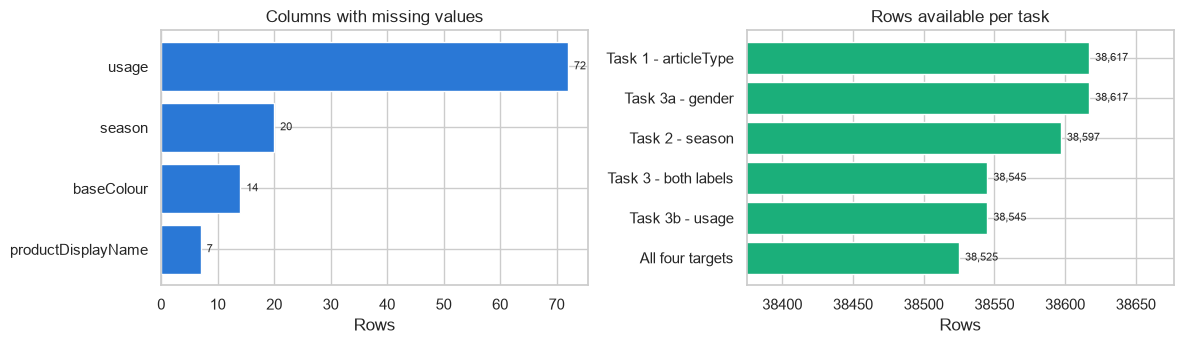

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
plot_missing = missing_table.sort_values("Missing")
axes[0].barh(plot_missing.index, plot_missing["Missing"], color=PALETTE[0])
axes[0].set(title="Columns with missing values", xlabel="Rows")
for y, value in enumerate(plot_missing["Missing"]):
    axes[0].text(value, y, f"  {value:,}", va="center", fontsize=8)

available = task_availability.sort_values("Labelled rows")
axes[1].barh(available["Task"], available["Labelled rows"], color=PALETTE[2])
axes[1].set(title="Rows available per task", xlabel="Rows",
            xlim=(available["Labelled rows"].min() - 150, len(metadata_df) + 60))
for y, value in enumerate(available["Labelled rows"]):
    axes[1].text(value, y, f"  {value:,}", va="center", fontsize=8)
plt.tight_layout();
plt.show();

`articleType` and `gender` are complete across all 38,617 rows. `season` is missing on 20 rows, `usage` on 72, `baseColour` on 14, and `productDisplayName` on 7.

At metadata level, Task 1 and Task 3a have 38,617 usable rows, Task 2 has 38,597, Task 3b has 38,545, and only 38,525 rows contain all four labels. A global filter would discard 92 otherwise valid examples, so `model_ready` carries one boolean validity flag per task.

These counts distinguish label missingness from later image availability. Reporting the task-specific denominator is important because a model evaluated on Task 2 or Task 3b does not see exactly the same candidate rows as Task 1, even before conflict resolution.

## 1.4 Does every row have an image?

Metadata rows and image files are matched by filename stem in both directions.

In [30]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

manifest_rows = []
non_image_files = []
for path in sorted(TRAIN_IMAGE_DIR.iterdir(), key=lambda p: p.name.lower()):
    if not path.is_file():
        continue
    if path.suffix.lower() not in IMAGE_EXTENSIONS:
        non_image_files.append(path.name)
        continue
    try:
        image_id = int(path.stem)
    except ValueError:
        continue
    manifest_rows.append({"id": image_id, "filename": path.name, "path": str(path.resolve())})

image_manifest = pd.DataFrame(manifest_rows)
metadata_ids = set(metadata_df["id"])
image_ids = set(image_manifest["id"])

linkage_summary = pd.DataFrame([
    ["Metadata rows", len(metadata_df)],
    ["Image files found", len(image_manifest)],
    ["Metadata rows with an image", len(metadata_ids & image_ids)],
    ["Metadata rows without an image", len(metadata_ids - image_ids)],
    ["Images without metadata", len(image_ids - metadata_ids)],
    ["Duplicate image-derived ids", int(image_manifest["id"].duplicated().sum())],
    ["Non-image files ignored", len(non_image_files)],
], columns=["Linkage measure", "Count"])
display(linkage_summary)

print("Metadata ids without an image:", sorted(metadata_ids - image_ids)[:20])
assert image_manifest["id"].is_unique

,Linkage measure,Count
0,Metadata rows,38617
1,Image files found,38612
2,Metadata rows with an image,38612
3,Metadata rows without an image,5
4,Images without metadata,0
5,Duplicate image-derived ids,0
6,Non-image files ignored,0


Metadata ids without an image: [12347, 39401, 39403, 39410, 39425]


38,612 of 38,617 rows have a matching image; no image file lacks metadata. Missing files are IDs `12347`, `39401`, `39403`, `39410`, and `39425`.

ID `12347` is the only `Suits` record, so image-based tasks observe 124 article types while metadata contains 125. The five rows are excluded from image modelling and reported explicitly; replacement images are out of scope.

The missing-image audit also prevents a misleading statement that the 125 metadata classes are all available to an image model. Keeping the raw metadata count alongside the image-observed count makes the class loss visible in later reports.

## 1.5 Are the image files usable, and what should we record about them?

The image audit records decodability, dimensions, colour mode, and SHA-256 digest—the properties needed for modelling and duplicate control.

In [31]:
audit_rows = []
for row in image_manifest.itertuples(index=False):
    path = Path(row.path)
    record = {
        "id": int(row.id), "filename": row.filename, "path": str(path),
        "file_bytes": path.stat().st_size, "readable": False, "format": None,
        "width": np.nan, "height": np.nan, "aspect_ratio": np.nan,
        "mode": None, "is_grayscale": False, "sha256": None, "error": None,
    }
    try:
        raw_bytes = path.read_bytes()
        record["sha256"] = hashlib.sha256(raw_bytes).hexdigest()
        with Image.open(BytesIO(raw_bytes)) as image:
            image.verify()
        with Image.open(BytesIO(raw_bytes)) as image:
            detected_format = image.format
            image = ImageOps.exif_transpose(image)
            record.update({
                "readable": True, "format": detected_format,
                "width": image.width, "height": image.height,
                "aspect_ratio": image.width / image.height,
                "mode": image.mode, "is_grayscale": image.mode in {"1", "L", "I", "F"},
            })
    except Exception as error:
        record["error"] = f"{type(error).__name__}: {error}"
    audit_rows.append(record)

image_audit_df = pd.DataFrame(audit_rows)
readable_audit = image_audit_df.loc[image_audit_df["readable"]].copy()

display(pd.DataFrame([
    ["Linked image files", len(image_audit_df)],
    ["Readable", int(image_audit_df["readable"].sum())],
    ["Unreadable / corrupt", int((~image_audit_df["readable"]).sum())],
    ["Empty files", int(image_audit_df["file_bytes"].eq(0).sum())],
], columns=["Integrity measure", "Images"]))

,Integrity measure,Images
0,Linked image files,38612
1,Readable,38612
2,Unreadable / corrupt,0
3,Empty files,0


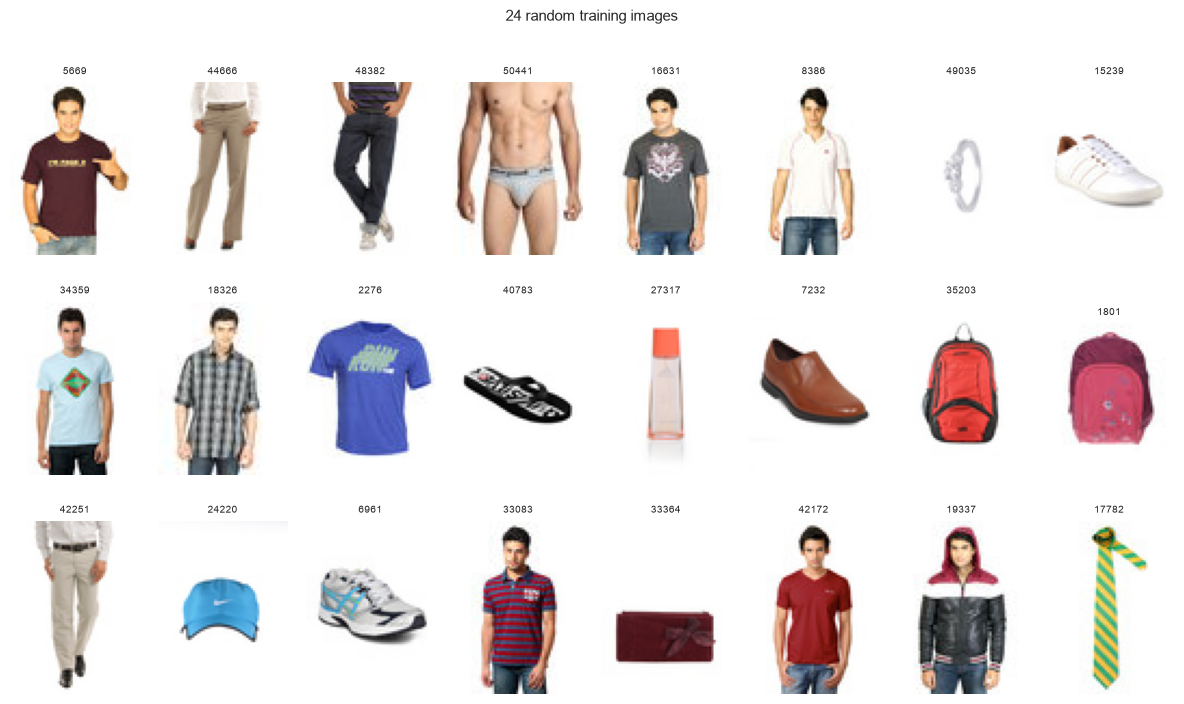

In [32]:
# What are we actually looking at? A plain sample first, before any statistics.
random_sample = sample_paths(readable_audit, 24)
show_image_grid(
    [[(r.path, str(r.id)) for r in random_sample[i:i + 8]] for i in range(0, len(random_sample), 8)],
    title="24 random training images",
)

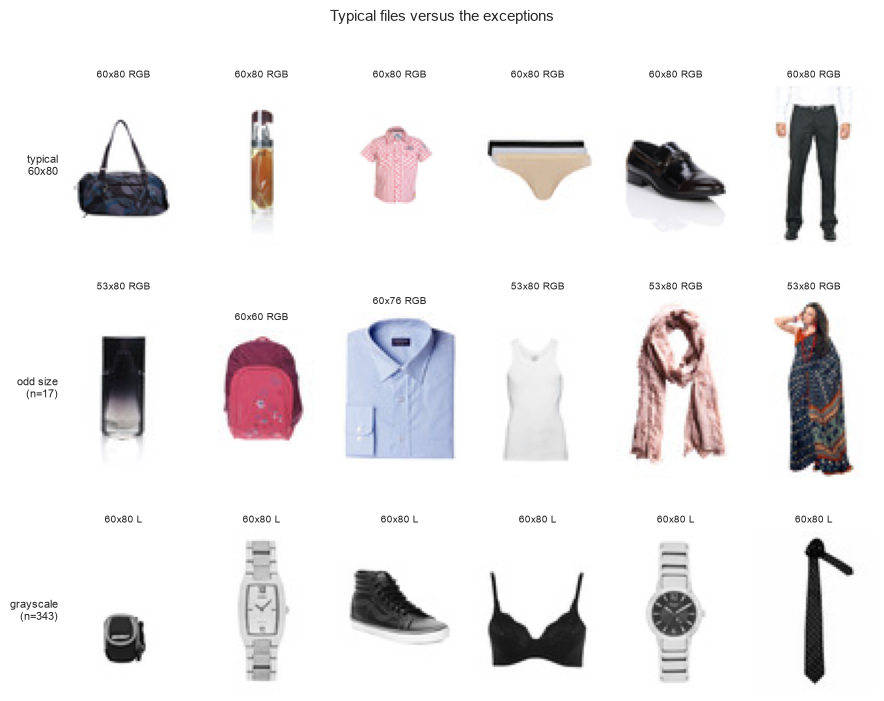

In [33]:
# Now the files that are NOT typical, since those are what the transform has to survive.
modal_dimensions = readable_audit.groupby(["width", "height"]).size().idxmax()
odd_sized = readable_audit.loc[
    (readable_audit["width"] != modal_dimensions[0]) | (readable_audit["height"] != modal_dimensions[1])
]
grayscale_files = readable_audit.loc[readable_audit["is_grayscale"]]

typical_row = [(r.path, f"{int(r.width)}x{int(r.height)} {r.mode}") for r in sample_paths(
    readable_audit.loc[readable_audit["width"].eq(modal_dimensions[0])
                       & readable_audit["height"].eq(modal_dimensions[1])
                       & ~readable_audit["is_grayscale"]], 6, seed_offset=1)]
odd_row = [(r.path, f"{int(r.width)}x{int(r.height)} {r.mode}") for r in sample_paths(odd_sized, 6, seed_offset=2)]
gray_row = [(r.path, f"{int(r.width)}x{int(r.height)} {r.mode}") for r in sample_paths(grayscale_files, 6, seed_offset=3)]

show_image_grid(
    [row for row in [typical_row, odd_row, gray_row] if row],
    row_labels=[label for label, row in
                [(f"typical\n{modal_dimensions[0]}x{modal_dimensions[1]}", typical_row),
                 (f"odd size\n(n={len(odd_sized)})", odd_row),
                 (f"grayscale\n(n={len(grayscale_files)})", gray_row)] if row],
    title="Typical files versus the exceptions",
)

All 38,612 linked files decode successfully and are JPEGs; there are no corrupt or zero-byte files. The five absent images are therefore the only image-side row loss.

The sample grids show a consistent studio catalogue: centred products, white backgrounds, and similar framing. Odd-sized and grayscale files are valid products, so the transform handles them rather than dropping rows. Pixel statistics are deferred because normalisation must be fitted on training rows after a split.

The technical consistency supports a simple common transform rather than separate pipelines for multiple image formats. It also means that any later model failure is unlikely to be explained by unreadable files or a broad mix of photographic conventions. The white studio background is common across classes, so it should not be treated as a class-specific visual signal.

The observed file properties also constrain the interpretation of later preprocessing experiments. A model evaluated at a larger tensor size is seeing an interpolation of small catalogue images, not new visual detail. The audit therefore establishes a meaningful native-resolution baseline against which larger backbones or augmentation policies can be assessed.

## 1.6 Are any images duplicates of each other?

Exact duplicates are identified from SHA-256 file hashes to control split leakage and expose conflicting supervision.

In [34]:
hash_counts = readable_audit["sha256"].value_counts()
duplicate_hashes = hash_counts[hash_counts > 1]
duplicate_members = readable_audit.loc[
    readable_audit["sha256"].isin(duplicate_hashes.index), ["id", "sha256"]
].merge(metadata_df[["id", *TARGETS]], on="id", how="left")

display(pd.Series({
    "readable images": len(readable_audit),
    "unique SHA-256 hashes": readable_audit["sha256"].nunique(),
    "duplicate groups": len(duplicate_hashes),
    "images in duplicate groups": int(duplicate_hashes.sum()),
    "largest duplicate group": int(duplicate_hashes.max()) if len(duplicate_hashes) else 1,
}, name="value").to_frame())

if len(duplicate_members):
    conflicts = duplicate_members.groupby("sha256")[TARGETS].nunique().gt(1).sum()
    display(conflicts.rename("groups with conflicting labels").to_frame())

,value
readable images,38612
unique SHA-256 hashes,37849
duplicate groups,636
images in duplicate groups,1399
largest duplicate group,4


,groups with conflicting labels
articleType,7
season,8
gender,7
usage,3


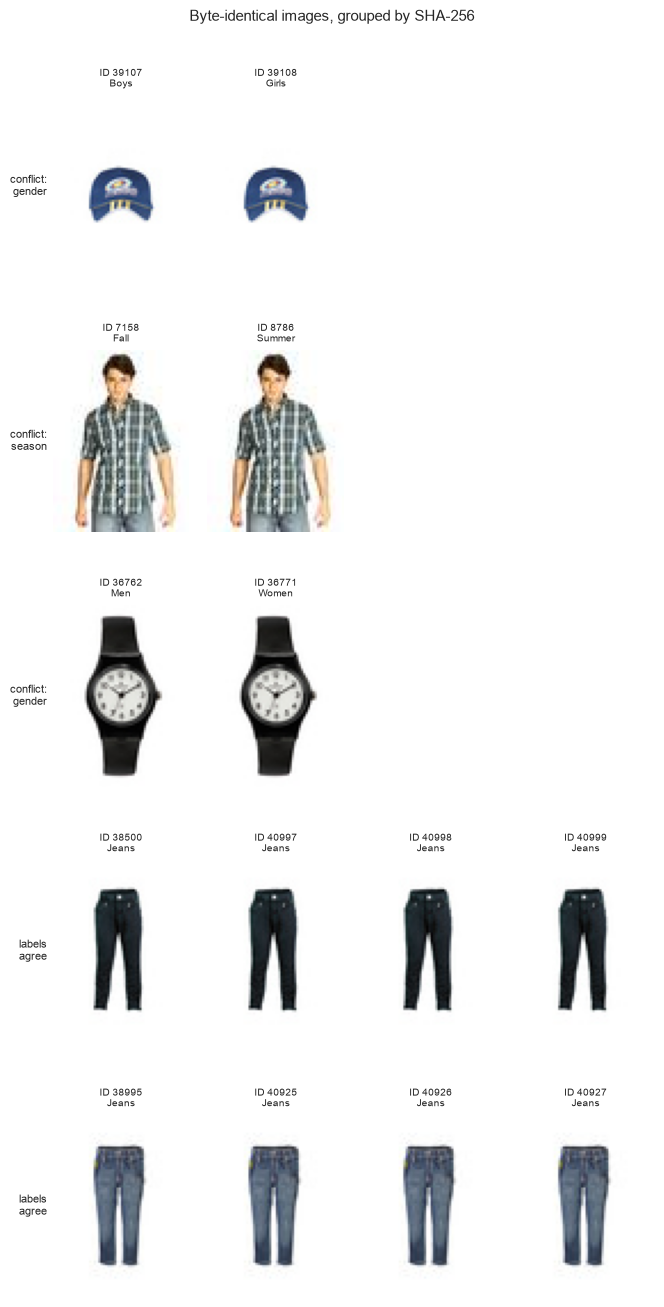

In [35]:
# Show duplicate groups as images, conflicting-label groups first - this is the label-noise evidence.
group_labels = duplicate_members.groupby("sha256")[TARGETS].nunique()
conflicting_hashes = group_labels.loc[group_labels.gt(1).any(axis=1)].index.tolist()
clean_hashes = [h for h in duplicate_hashes.index if h not in conflicting_hashes]

paths_by_id = readable_audit.set_index("id")["path"]
grid_rows, grid_labels = [], []
for digest in (conflicting_hashes[:3] + clean_hashes[:2]):
    members = duplicate_members.loc[duplicate_members["sha256"].eq(digest)]
    disagreeing = [t for t in TARGETS if members[t].nunique(dropna=True) > 1]
    row = []
    for member in members.itertuples(index=False):
        caption = f"ID {member.id}"
        for target in (disagreeing or ["articleType"]):
            caption += f"\n{getattr(member, target)}"
        row.append((paths_by_id.loc[member.id], caption))
    grid_rows.append(row)
    grid_labels.append(("conflict:\n" + ", ".join(disagreeing)) if disagreeing else "labels\nagree")

if grid_rows:
    show_image_grid(grid_rows, row_labels=grid_labels, scale=1.7,
                    title="Byte-identical images, grouped by SHA-256")

There are 636 duplicate groups covering 1,399 images; the largest group contains four copies. Conflicting labels occur in 7 groups for `articleType`, 8 for `season`, 7 for `gender`, and 3 for `usage`.

Raw rows and JPEGs remain unchanged. The digest is carried as `group_id`, so a split can keep byte-identical images on one side. Only the explicit decisions in §3.2 update or remove records from the corresponding task frame; all other rows remain available to that task.

Hashes detect exact copies only. Alternate views, colourways, and reshoots may still cross a split; perceptual hashing is a stated limitation rather than part of this preprocessing.

**Duplicate-group risks.**

- **Leakage:** splitting a group lets validation reward memorising training pixels.
- **Contradictory supervision:** conflicting labels teach different answers for the same image.
- **Control:** `group_id` prevents split leakage; §3.2 applies only the documented label decisions.

## 1.7 Assembling `model_ready`

The audited metadata and image manifest are combined into the shared table used by all task sections.

In [76]:
manifest_link = image_manifest[["id", "filename", "path"]]
audit_flags = image_audit_df[["id", "readable", "sha256"]]

analysis_df = (
    metadata_df
    .merge(manifest_link, on="id", how="left")
    .merge(audit_flags, on="id", how="left")
)

model_ready = (
    analysis_df.loc[analysis_df["readable"].eq(True)]
    .drop(columns="readable")
    .rename(columns={"sha256": "group_id"})
    .reset_index(drop=True)
)

population_table = pd.DataFrame([
    ["Cleaned metadata rows", len(analysis_df)],
    ["Usable images (model_ready)", len(model_ready)],
    ["Task 1 - articleType", int(model_ready["articleType"].notna().sum())],
    ["Task 2 - season", int(model_ready["season"].notna().sum())],
    ["Task 3a - gender", int(model_ready["gender"].notna().sum())],
    ["Task 3b - usage", int(model_ready["usage"].notna().sum())],
    ["Task 4 - retrieval pool", len(model_ready)],
], columns=["Population", "Rows"])

display(population_table)

,Population,Rows
0,Cleaned metadata rows,38617
1,Usable images (model_ready),38612
2,Task 1 - articleType,38612
3,Task 2 - season,38592
4,Task 3a - gender,38612
5,Task 3b - usage,38540
6,Task 4 - retrieval pool,38612


`model_ready` reconciles to 38,617 cleaned metadata rows in and 38,612 image-usable rows out—the five-row difference is exactly the missing-image set.

After image filtering, Task 1 and Task 3a have 38,612 rows, Task 2 has 38,592, Task 3b has 38,540, and Task 4 uses all 38,612 rows as its retrieval pool. Metadata columns, labels, filenames, paths, and `group_id` remain available for downstream filtering.

The table is intentionally broad enough for both classification and retrieval: classification tasks select their valid labels, while retrieval needs all readable image records. No global row drop is applied after the audit, which keeps this shared object reusable across the assignment.

# 2. What is difficult about this data?

## 2.1 How are the labels distributed?

This section assesses support, imbalance, visual ambiguity, and which information is available at inference.

,Target,Labelled images,Classes,Largest class,Largest support,Largest share %,Smallest support
0,articleType,38612,124,Tshirts,6780,17.6%,1
1,season,38592,4,Summer,19135,49.6%,1566
2,gender,38612,5,Men,20913,54.2%,645
3,usage,38540,8,Casual,29636,76.9%,1


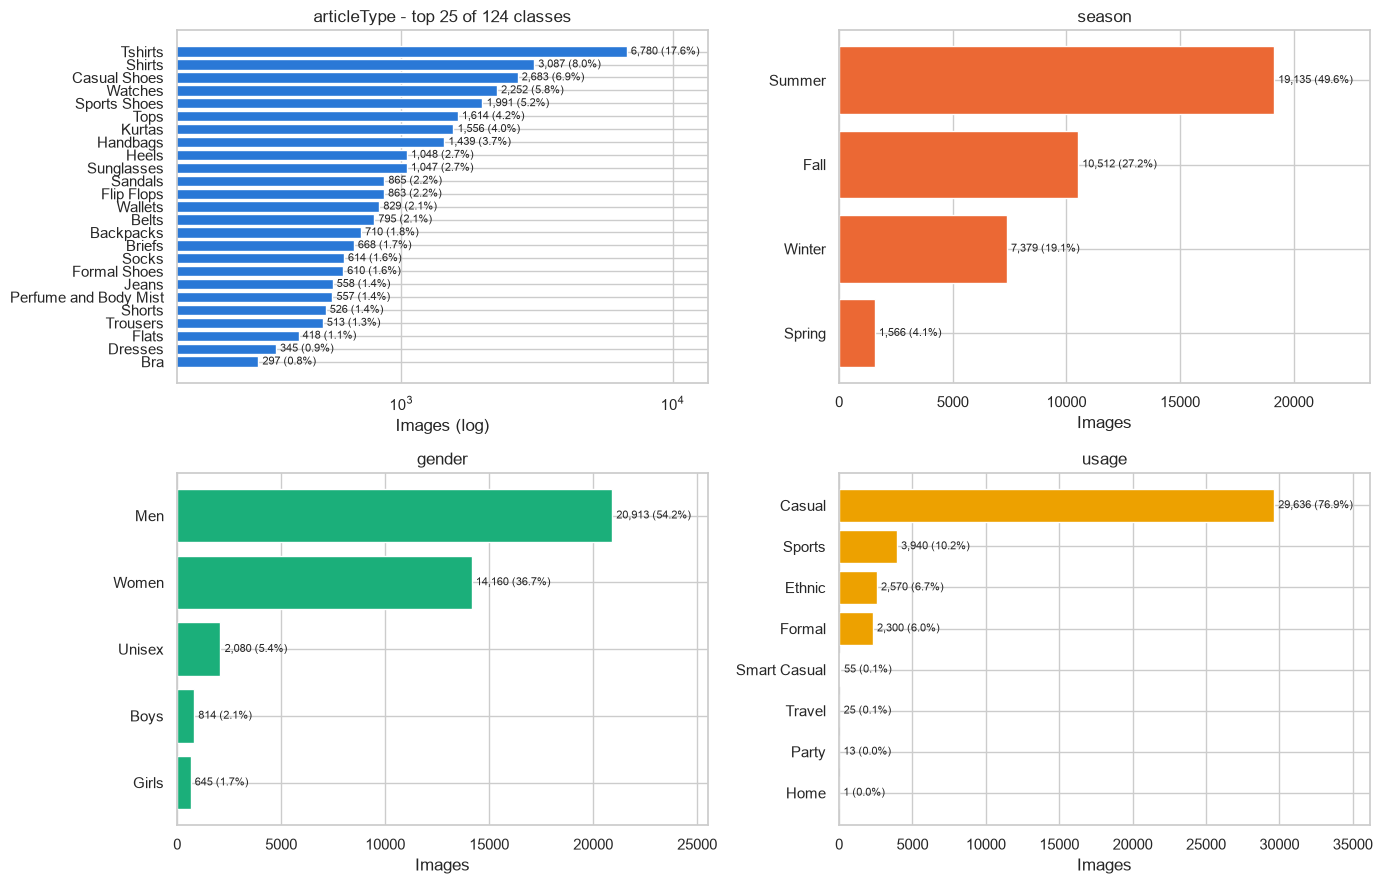

In [77]:
target_counts = {t: model_ready.loc[model_ready[t].notna(), t].value_counts() for t in TARGETS}

target_summary = pd.DataFrame([
    {
        "Target": t,
        "Labelled images": int(counts.sum()),
        "Classes": len(counts),
        "Largest class": counts.index[0],
        "Largest support": int(counts.iloc[0]),
        "Largest share %": counts.iloc[0] / counts.sum() * 100,
        "Smallest support": int(counts.iloc[-1]),
    }
    for t, counts in target_counts.items()
])
display(target_summary.style.format({"Largest share %": "{:.1f}%"}))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, target, color in zip(axes.flat, TARGETS, PALETTE[:4]):
    counts = target_counts[target]
    shown = (counts.head(25) if target == "articleType" else counts).sort_values()
    bars = ax.barh(shown.index, shown.values, color=color)
    total = counts.sum()
    labels = [f"{value:,} ({value / total:.1%})" for value in shown.values]
    ax.bar_label(bars, labels=labels, padding=3, fontsize=8)
    if target == "articleType":
        ax.set_xscale("log")
        ax.set(title=f"articleType - top 25 of {len(counts)} classes", xlabel="Images (log)")
    else:
        ax.set(title=target, xlabel="Images")
    ax.set_ylabel("")
    ax.margins(x=0.22)  # leave room for count-and-percentage labels
plt.tight_layout(); plt.show()

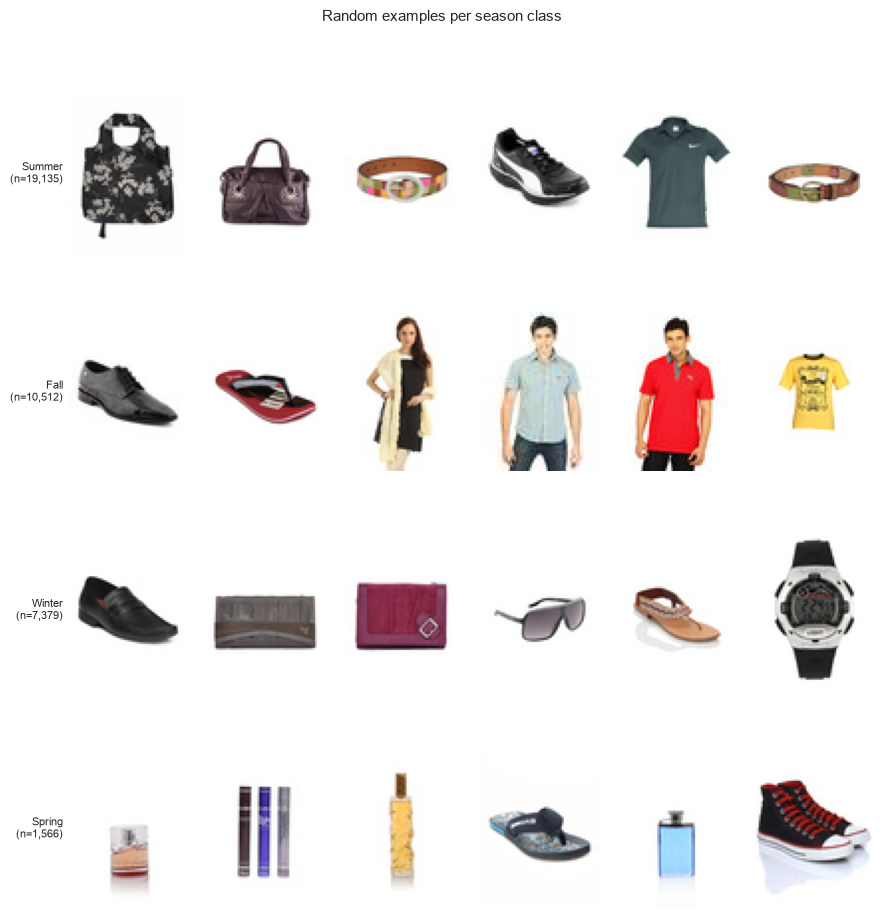

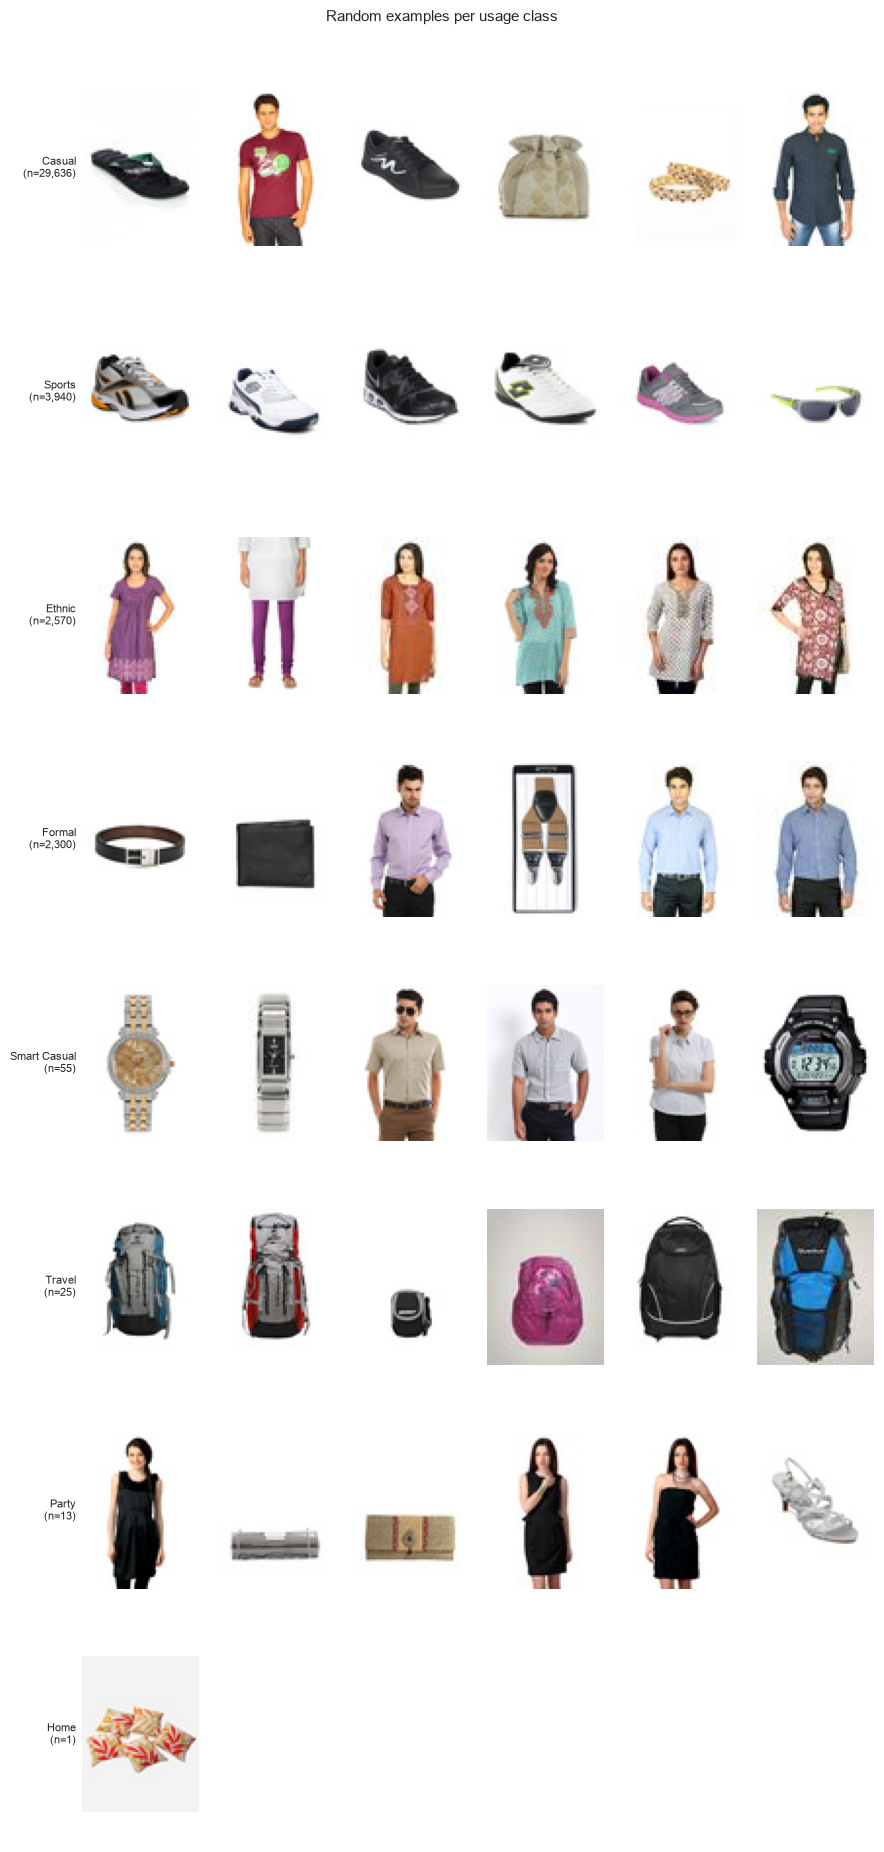

In [78]:
# Does the label look like anything? Same number of examples per class, drawn deterministically.
for target in ["season", "usage"]:
    classes = target_counts[target].index.tolist()
    rows, labels = [], []
    for label in classes:
        members = model_ready.loc[model_ready[target].eq(label), ["id", "path"]]
        picked = sample_paths(members, 6, seed_offset=hash(label) % 100)
        if picked:
            rows.append([(r.path, "") for r in picked])
            labels.append(f"{label}\n(n={target_counts[target][label]:,})")
    show_image_grid(rows, row_labels=labels, title=f"Random examples per {target} class")

The targets have different class structures:

- `articleType`: 124 classes; Tshirts has 6,780 images (17.6%), while the smallest class has one image.
- `season`: 4 classes; Summer has 19,135 images (49.6%).
- `gender`: 5 classes; Men has 20,913 images (54.2%).
- `usage`: 8 classes; Casual has 29,636 of 38,540 images (76.9%).

Accuracy alone is misleading, particularly for `usage`; headline results should include macro-averaged metrics. The image grids also suggest that season is a weakly visual merchandising label, so Task 2 may be difficult despite its small label space.

**Implications for evaluation.**

- The majority baseline is especially deceptive for `usage`.
- `articleType` combines a large label space with a severe long tail.
- `season` and `gender` may depend on weak or indirect visual cues.
- Each task should use an appropriate baseline and class-aware metrics.

The imbalance is not identical across tasks, so a single score cannot summarize the dataset's difficulty. Task reports should include the majority baseline, macro score, and selected per-class behaviour where the tail or semantically weak labels materially affect the conclusion.

## 2.2 How bad is the long tail?

Class support determines whether a target can be learned and evaluated reliably.

,Target,Classes,Max/min ratio,Median support,Singleton classes,Classes < 5,Classes < 10,Top-class share %
0,articleType,124,"6,780.0",43.5,6,21,32,17.6%
1,season,4,12.2,"8,945.5",0,0,0,49.6%
2,gender,5,32.4,"2,080.0",0,0,0,54.2%
3,usage,8,"29,636.0","1,177.5",1,1,1,76.9%


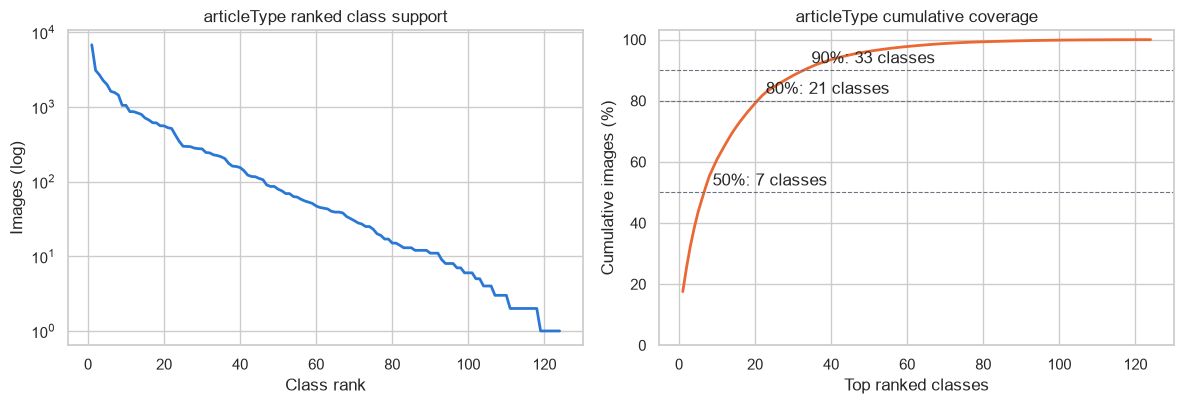

Classes needed for 50/80/90% of images: {50: 7, 80: 21, 90: 33}

Rare articleType classes (< 5 images):
{'Compact': 4, 'Lip Plumper': 4, 'Highlighter and Blush': 4, 'Hat': 3, 'Shrug': 3, 'Tablet Sleeve': 3, 'Trolley Bag': 3, 'Lehenga Choli': 2, 'Key chain': 2, 'Robe': 2, 'Shapewear': 2, 'Concealer': 2, 'Baby Dolls': 2, 'Rain Jacket': 2, 'Rain Trousers': 2, 'Shoe Laces': 1, 'Ties and Cufflinks': 1, 'Cushion Covers': 1, 'Body Wash and Scrub': 1, 'Ipad': 1, 'Lounge Tshirts': 1}


In [79]:
imbalance_table = pd.DataFrame([
    {
        "Target": t,
        "Classes": len(counts),
        "Max/min ratio": counts.max() / counts.min(),
        "Median support": counts.median(),
        "Singleton classes": int((counts == 1).sum()),
        "Classes < 5": int((counts < 5).sum()),
        "Classes < 10": int((counts < 10).sum()),
        "Top-class share %": counts.max() / counts.sum() * 100,
    }
    for t, counts in target_counts.items()
])
display(imbalance_table.style.format({
    "Max/min ratio": "{:,.1f}", "Median support": "{:,.1f}", "Top-class share %": "{:.1f}%",
}))

article_counts = target_counts["articleType"].sort_values(ascending=False)
cumulative = article_counts.cumsum() / article_counts.sum() * 100
coverage = {t: int(np.searchsorted(cumulative.values, t) + 1) for t in [50, 80, 90]}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(np.arange(1, len(article_counts) + 1), article_counts.values, color=PALETTE[0], lw=2)
axes[0].set_yscale("log")
axes[0].set(title="articleType ranked class support", xlabel="Class rank", ylabel="Images (log)")
axes[1].plot(np.arange(1, len(cumulative) + 1), cumulative.values, color=PALETTE[1], lw=2)
for threshold, n_classes in coverage.items():
    axes[1].axhline(threshold, color=MUTED, ls="--", lw=0.8)
    axes[1].annotate(f"{threshold}%: {n_classes} classes", (n_classes, threshold),
                     xytext=(5, 5), textcoords="offset points")
axes[1].set(title="articleType cumulative coverage", xlabel="Top ranked classes",
            ylabel="Cumulative images (%)", ylim=(0, 103))
plt.tight_layout(); plt.show()
print("Classes needed for 50/80/90% of images:", coverage)

print("\nRare articleType classes (< 5 images):")
print(article_counts[article_counts < 5].to_dict())

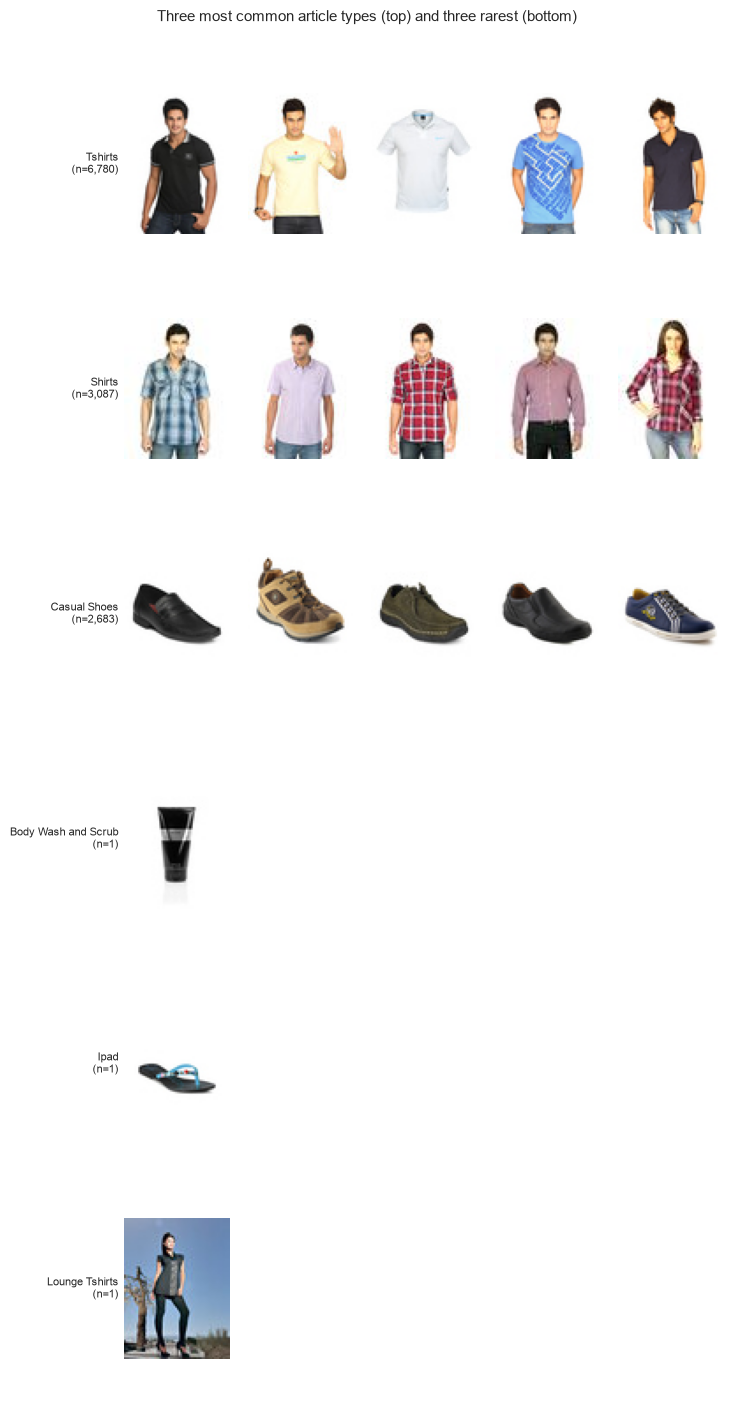

In [81]:
# The head and the tail of the articleType distribution, side by side.
head_classes = article_counts.head(3).index.tolist()
tail_classes = article_counts.tail(3).index.tolist()
rows, labels = [], []
for label in head_classes + tail_classes:
    members = model_ready.loc[model_ready["articleType"].eq(label), ["id", "path"]]
    picked = sample_paths(members, 5, seed_offset=hash(label) % 100)
    rows.append([(r.path, "") for r in picked])
    labels.append(f"{label}\n(n={article_counts[label]:,})")
show_image_grid(rows, row_labels=labels,
                title="Three most common article types (top) and three rarest (bottom)")

`articleType` ranges from 6,780 to 1 image per class (6,780:1): 32 classes have fewer than 10 images, 21 have fewer than 5, and 6 are singletons. Seven classes cover 50% of images, 21 cover 80%, and 33 cover 90%.

`usage` has only 8 labels but also spans 29,636:1 because one class is a singleton. A singleton cannot be both trainable and evaluable in a hold-out split.

All classes and rows are retained. Rare classes are not merged or oversampled before splitting; macro metrics, class weighting, and post-split sampling remain task-level choices. Per-class results must be interpreted with their support counts.

The long tail is not removed because doing so would change the assignment label space and make aggregate results easier by deleting difficult cases. It instead sets expectations for validation coverage: some classes necessarily appear only in training, and many low-support classes will have high-variance per-class estimates.

## 2.3 Which classes look alike to a model?

Class mean images are used as a pre-training diagnostic for visually similar labels.

In [82]:
CONFUSABILITY_MIN_SUPPORT = 30
MEAN_IMAGE_SIZE = (60, 80)  # width, height

article_support = target_counts["articleType"]
confusable_classes = sorted(article_support[article_support >= CONFUSABILITY_MIN_SUPPORT].index)
print(f"{len(confusable_classes)} of {len(article_support)} article types have "
      f">= {CONFUSABILITY_MIN_SUPPORT} images and get a mean image.")

mean_sums = {label: np.zeros((MEAN_IMAGE_SIZE[1], MEAN_IMAGE_SIZE[0], 3), dtype=np.float64)
             for label in confusable_classes}
mean_counts = Counter()
for row in model_ready.loc[model_ready["articleType"].isin(confusable_classes),
                           ["path", "articleType"]].itertuples(index=False):
    with Image.open(row.path) as image:
        pixels = np.asarray(
            ImageOps.fit(ImageOps.exif_transpose(image).convert("RGB"), MEAN_IMAGE_SIZE),
            dtype=np.float32,
        )
    mean_sums[row.articleType] += pixels
    mean_counts[row.articleType] += 1

class_mean_images = {label: mean_sums[label] / mean_counts[label] for label in confusable_classes}

70 of 124 article types have >= 30 images and get a mean image.


In [83]:
# Centre each mean image before normalising so overall brightness does not dominate similarity.
mean_matrix = np.stack([class_mean_images[label].reshape(-1) for label in confusable_classes])
mean_matrix = mean_matrix - mean_matrix.mean(axis=1, keepdims=True)
mean_matrix /= np.linalg.norm(mean_matrix, axis=1, keepdims=True)
mean_similarity = mean_matrix @ mean_matrix.T

# The product family each article type belongs to, used to flag cross-family confusion.
family_of = (
    model_ready.dropna(subset=["articleType", "subCategory"])
    .groupby("articleType")["subCategory"]
    .agg(lambda s: s.value_counts().index[0])
)

pairs = []
for a in range(len(confusable_classes)):
    for b in range(a + 1, len(confusable_classes)):
        left, right = confusable_classes[a], confusable_classes[b]
        pairs.append({
            "articleType A": left,
            "articleType B": right,
            "similarity": mean_similarity[a, b],
            "family A": family_of.get(left, "unknown"),
            "family B": family_of.get(right, "unknown"),
            "different_product_family": family_of.get(left) != family_of.get(right),
            "support A": int(mean_counts[left]),
            "support B": int(mean_counts[right]),
        })
confusable_pairs = pd.DataFrame(pairs).sort_values("similarity", ascending=False).reset_index(drop=True)

print("Most similar pairs overall:")
display(confusable_pairs.head(10).style.format({"similarity": "{:.3f}"}))

cross_family = confusable_pairs.loc[confusable_pairs["different_product_family"]]
print("Most similar pairs from DIFFERENT product families - genuinely different objects "
      "that the catalogue photographs alike:")
display(cross_family.head(10).style.format({"similarity": "{:.3f}"}))

Most similar pairs overall:


,articleType A,articleType B,similarity,family A,family B,different_product_family,support A,support B
0,Kurtis,Tunics,0.992,Topwear,Topwear,False,203,175
1,Tops,Tunics,0.989,Topwear,Topwear,False,1614,175
2,Jackets,Sweatshirts,0.989,Topwear,Topwear,False,228,280
3,Kurtas,Tunics,0.986,Topwear,Topwear,False,1556,175
4,Flats,Heels,0.985,Shoes,Shoes,False,418,1048
5,Kurtis,Tops,0.984,Topwear,Topwear,False,203,1614
6,Laptop Bag,Messenger Bag,0.983,Bags,Bags,False,79,43
7,Sweaters,Sweatshirts,0.983,Topwear,Topwear,False,276,280
8,Sandals,Sports Sandals,0.982,Sandal,Sandal,False,865,63
9,Kurtas,Stoles,0.982,Topwear,Stoles,True,1556,90


Most similar pairs from DIFFERENT product families - genuinely different objects that the catalogue photographs alike:


,articleType A,articleType B,similarity,family A,family B,different_product_family,support A,support B
9,Kurtas,Stoles,0.982,Topwear,Stoles,True,1556,90
11,Stoles,Tops,0.979,Stoles,Topwear,True,90,1614
12,Stoles,Tunics,0.978,Stoles,Topwear,True,90,175
15,Innerwear Vests,Tshirts,0.974,Innerwear,Topwear,True,242,6780
17,Kurtis,Stoles,0.972,Topwear,Stoles,True,203,90
19,Casual Shoes,Sports Sandals,0.971,Shoes,Sandal,True,2683,63
21,Casual Shoes,Sandals,0.970,Shoes,Sandal,True,2683,865
22,Leggings,Lounge Pants,0.969,Bottomwear,Loungewear and Nightwear,True,159,53
25,Messenger Bag,Wallets,0.963,Bags,Wallets,True,43,829
29,Dresses,Stoles,0.959,Dress,Stoles,True,345,90


Class means are compared by cosine similarity, excluding classes below `CONFUSABILITY_MIN_SUPPORT`. Rankings are separated into expected similarities within a product family and more informative similarities across different `subCategory` branches.

Specific pairs depend on the executed images and must be filled from the tables above. The accompanying real-image check matters because similar white-background averages can arise from framing rather than genuine item-level ambiguity.

Cross-family pairs are the most useful candidates for qualitative error analysis because they indicate that unrelated catalogue categories can share silhouette, framing, or colour at this resolution. The visual check prevents over-interpreting a high mean similarity that is driven by the standard white background alone.

Kurtas (Topwear) vs Stoles (Stoles) - cosine similarity 0.982


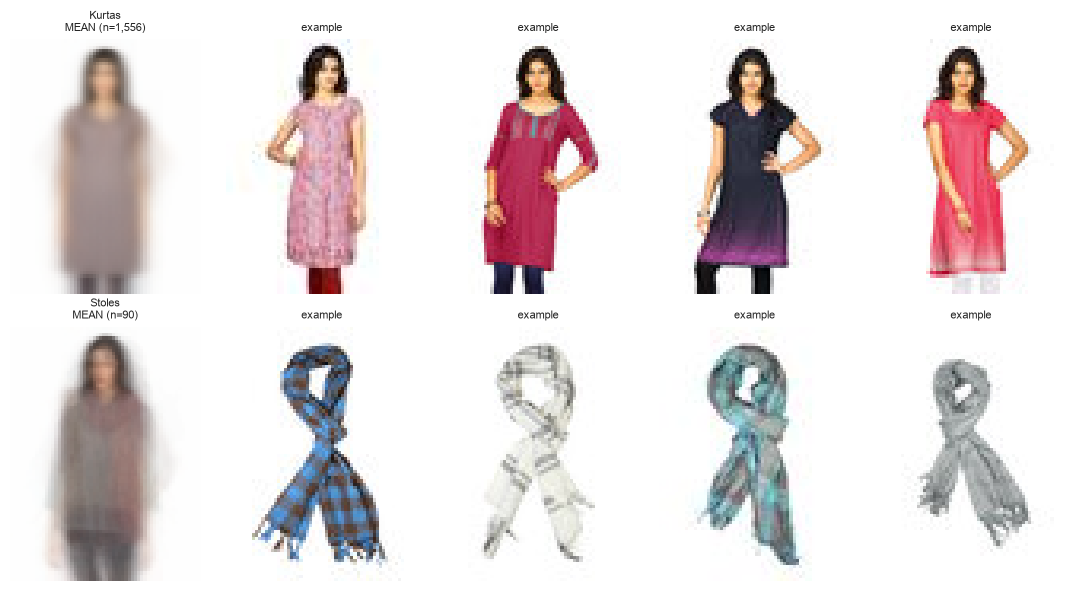

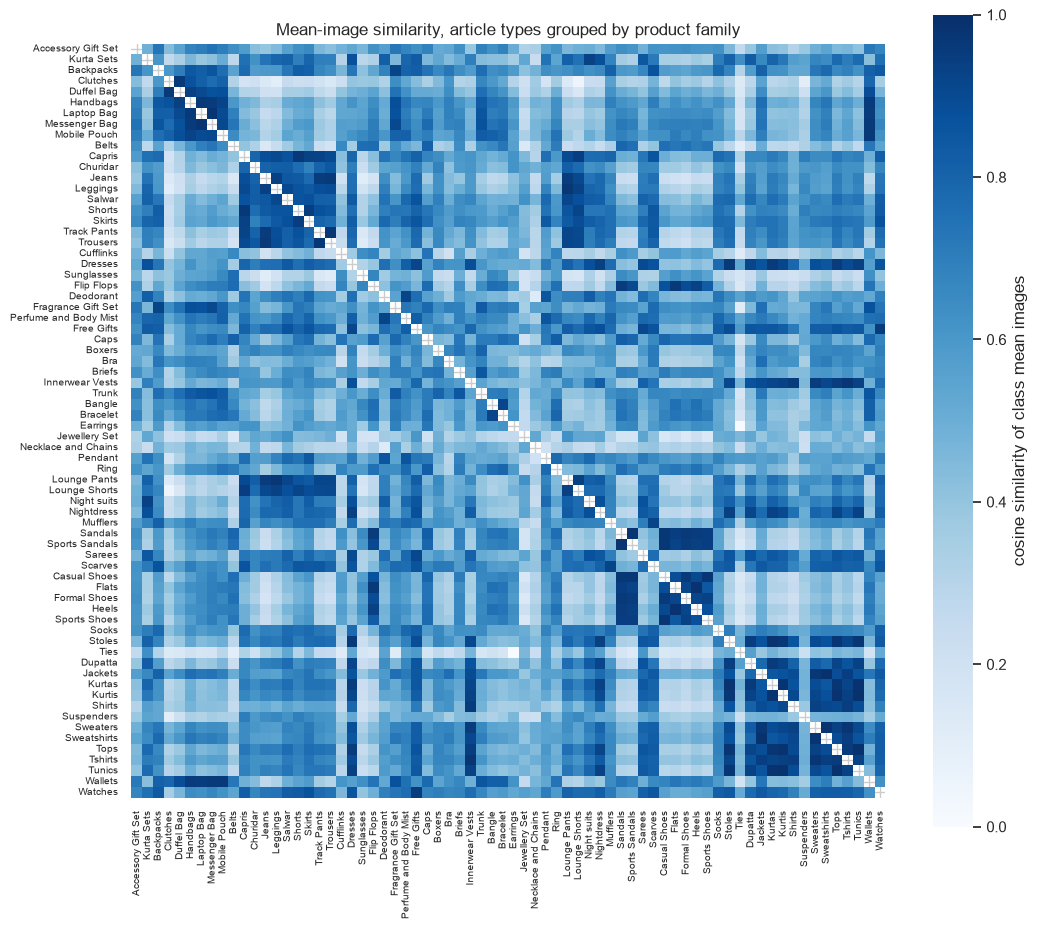

In [84]:
# Show the worst cross-family pair concretely: class means, then real examples of each.
assert len(cross_family), "No cross-family pairs; lower CONFUSABILITY_MIN_SUPPORT."
worst = cross_family.iloc[0]
pair_labels = [worst["articleType A"], worst["articleType B"]]
print(f"{pair_labels[0]} ({worst['family A']}) vs {pair_labels[1]} ({worst['family B']}) "
      f"- cosine similarity {worst['similarity']:.3f}")

fig, axes = plt.subplots(2, 5, figsize=(11, 6))
for row_index, label in enumerate(pair_labels):
    axes[row_index, 0].imshow(class_mean_images[label].astype(np.uint8))
    axes[row_index, 0].set_title(f"{label}\nMEAN (n={mean_counts[label]:,})", fontsize=8)
    examples = model_ready.loc[model_ready["articleType"].eq(label), "path"].head(4)
    for column, example_path in enumerate(examples, start=1):
        with Image.open(example_path) as image:
            axes[row_index, column].imshow(ImageOps.exif_transpose(image).convert("RGB"))
        axes[row_index, column].set_title("example", fontsize=8)
    for ax in axes[row_index]:
        ax.axis("off")
plt.tight_layout(); plt.show()

# Similarity structure across the whole label space, grouped so families form visible blocks.
heatmap_order = sorted(confusable_classes, key=lambda label: (family_of.get(label, "unknown"), label))
position = {label: index for index, label in enumerate(confusable_classes)}
ordered = mean_similarity[np.ix_([position[l] for l in heatmap_order],
                                 [position[l] for l in heatmap_order])].copy()
np.fill_diagonal(ordered, np.nan)

fig, ax = plt.subplots(figsize=(11, 9.5))
sns.heatmap(ordered, xticklabels=heatmap_order, yticklabels=heatmap_order,
            cmap="Blues", vmin=0, vmax=1, square=True, ax=ax,
            cbar_kws={"label": "cosine similarity of class mean images"})
ax.set_title("Mean-image similarity, article types grouped by product family")
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.tight_layout(); plt.show()

These are hypotheses, not model results. Task 1 should compare the ranked pairs with its confusion matrix: agreement supports a visual explanation, while disagreement points to label noise, imbalance, or optimisation instead.

## 2.4 Is Task 3 one label or two?

Gender and usage can be modelled as two heads or as one combined target; association and joint-label support determine the choice.

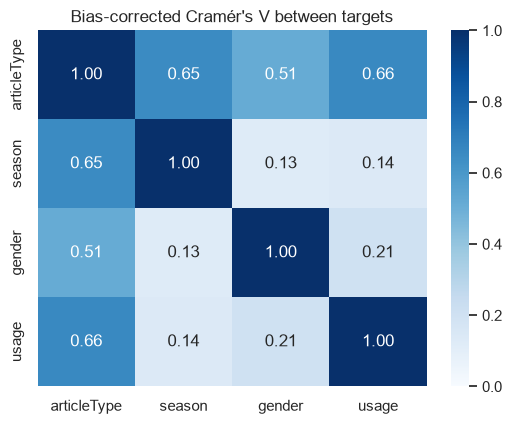

,value
possible combinations,40.0
observed combinations,24.0
combinations below 10 images,6.0
singleton combinations,3.0
largest/smallest ratio,15686.0


In [85]:
def corrected_cramers_v(x, y):
    table = pd.crosstab(x, y)
    if table.empty or min(table.shape) < 2:
        return np.nan
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    phi2 = chi2 / n
    r, k = table.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / max(n - 1, 1))
    r_corr = r - ((r - 1) ** 2) / max(n - 1, 1)
    k_corr = k - ((k - 1) ** 2) / max(n - 1, 1)
    denominator = min(k_corr - 1, r_corr - 1)
    return math.sqrt(phi2_corr / denominator) if denominator > 0 else np.nan


association = pd.DataFrame(index=TARGETS, columns=TARGETS, dtype=float)
for left in TARGETS:
    for right in TARGETS:
        pair = model_ready[[left, right]].dropna()
        association.loc[left, right] = (
            1.0 if left == right else corrected_cramers_v(pair[left], pair[right])
        )

fig, ax = plt.subplots(figsize=(5.5, 4.4))
sns.heatmap(association, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_title("Bias-corrected Cramér's V between targets")
plt.tight_layout(); plt.show()

combination_counts = (
    model_ready.dropna(subset=["gender", "usage"])
    .assign(gender_usage=lambda d: d["gender"].astype(str) + " | " + d["usage"].astype(str))
    ["gender_usage"].value_counts()
)
display(pd.Series({
    "possible combinations": model_ready["gender"].nunique() * model_ready["usage"].nunique(),
    "observed combinations": len(combination_counts),
    "combinations below 10 images": int((combination_counts < 10).sum()),
    "singleton combinations": int((combination_counts == 1).sum()),
    "largest/smallest ratio": combination_counts.max() / combination_counts.min(),
}, name="value").to_frame())

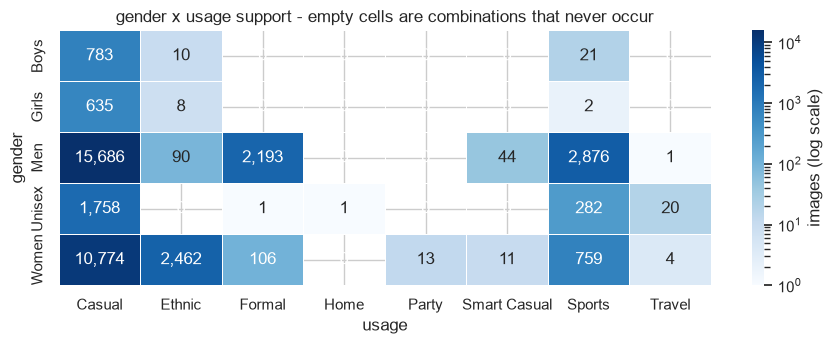

In [86]:
combination_matrix = pd.crosstab(model_ready["gender"], model_ready["usage"])
fig, ax = plt.subplots(figsize=(9, 3.6))
sns.heatmap(combination_matrix, annot=True, fmt=",d", cmap="Blues",
            norm=LogNorm(vmin=1, vmax=max(combination_matrix.to_numpy().max(), 2)),
            linewidths=0.5, linecolor="white", ax=ax, cbar_kws={"label": "images (log scale)"})
ax.set_title("gender x usage support - empty cells are combinations that never occur")
plt.tight_layout(); plt.show()

Gender and usage are related but not redundant. The 5 × 8 joint space permits 40 combinations, but only 24 occur; 6 have fewer than 10 images and 3 are singletons.

Two heads are used instead of a joint label. Each head keeps every row with its own label, while the other loss is masked when missing. This avoids a sparse 24-class target and preserves the 72 rows with gender but no usage.

This choice also preserves a clear evaluation contract: gender and usage can be scored independently on every row for which that label is known. A joint target would convert missingness into an artificial class-availability problem and obscure whether errors arise from gender, usage, or their combination.

## 2.5 Can the metadata columns be model inputs?

Metadata is evaluated for leakage and deployment compatibility, not merely predictive strength.

In [87]:
# How much of each target is already spelled out in the product name?
# Crude substring test (singular stem, case-insensitive) - it under-counts rather than over-counts.
leak_rows = []
for target in TARGETS:
    frame = model_ready.dropna(subset=["productDisplayName", target])
    contains = frame.apply(
        lambda row: str(row[target]).rstrip("s").lower() in row["productDisplayName"].lower(),
        axis=1,
    )
    leak_rows.append({
        "Target": target,
        "Rows with a product name": len(frame),
        "Label appears in the name": int(contains.sum()),
        "Share %": contains.mean() * 100,
    })
display(pd.DataFrame(leak_rows).style.format({"Share %": "{:.1f}%"}))

print("Example product names:")
for name in model_ready["productDisplayName"].dropna().head(5):
    print("  ", name)

,Target,Rows with a product name,Label appears in the name,Share %
0,articleType,38605,24276,62.9%
1,season,38585,25,0.1%
2,gender,38605,36677,95.0%
3,usage,38538,4103,10.6%


Example product names:
   Nike Sahara Team India Fanwear Round Neck Jersey
   Nike Men Blue T20 Indian Cricket Jersey
   Nike Mean Team India Cricket Jersey
   Puma Deck Navy Blue Backpack
   Puma Big Cat Backpack Black


`styles_prediction.csv` provides only `id` and the four targets; it does not include `masterCategory`, `subCategory`, `baseColour`, `year`, or `productDisplayName`. These fields are excluded from model inputs even though `productDisplayName` directly exposes gender for 95.0% of rows and article type for 62.9%.

The metadata remains in `model_ready` for diagnostics, including the product-family analysis in §2.3. Parent categories may support auxiliary supervision during training, but inference must still depend only on the image.

This is an inference-time constraint rather than a claim that metadata is uninformative. Using text or category fields directly would inflate validation metrics while producing a model that cannot run on the provided prediction file. The retained columns are consequently evidential and diagnostic, not model features.

# 3. General stateless preprocessing

## 3.1 Image properties, and the transform they imply

Image geometry is measured before selecting the common tensor transform.

In [88]:
dimension_counts = (
    readable_audit.groupby(["width", "height"]).size()
    .sort_values(ascending=False).rename("images")
)
mode_counts = readable_audit["mode"].value_counts().rename("images")

display(readable_audit[["file_bytes", "width", "height", "aspect_ratio"]].describe().T)
display(dimension_counts.head(10).to_frame())
display(mode_counts.to_frame())
print("Formats:", readable_audit["format"].value_counts().to_dict())
print(f"Grayscale images: {int(readable_audit['is_grayscale'].sum()):,} "
      f"({readable_audit['is_grayscale'].mean() * 100:.2f}%)")
print(f"Median aspect ratio (w/h): {readable_audit['aspect_ratio'].median():.3f}")

,count,mean,std,min,25%,50%,75%,max
file_bytes,38612.0,12480.446364,10059.295638,481.0000,2170.00,13831.00,20364.00,110353.0
width,38612.0,59.998550,0.100749,53.0000,60.00,60.00,60.00,60.0
height,38612.0,79.997022,0.230907,60.0000,80.00,80.00,80.00,80.0
aspect_ratio,38612.0,0.750018,0.003135,0.6625,0.75,0.75,0.75,1.0


images
width height        
60    80       38595
53    80           8
60    60           5
      77           2
      76           1
      75           1

,images
mode,
RGB,38269
L,343


Formats: {'JPEG': 38612}
Grayscale images: 343 (0.89%)
Median aspect ratio (w/h): 0.750


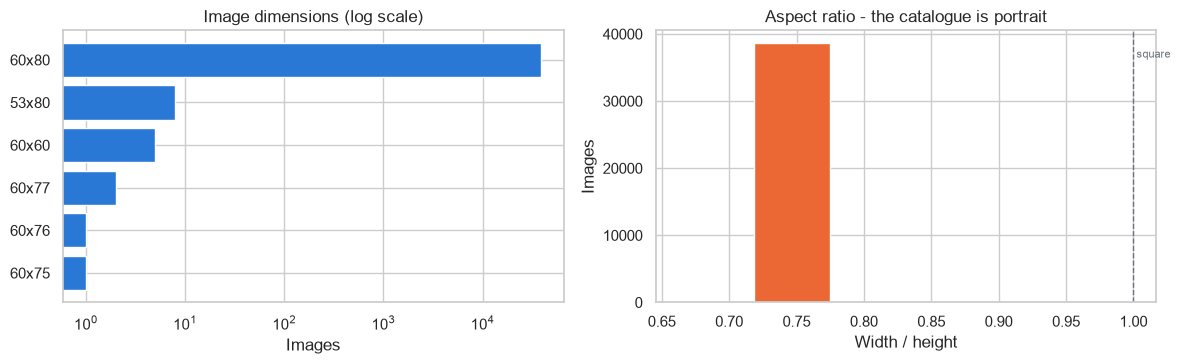

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
top_dimensions = dimension_counts.head(8).sort_values()
axes[0].barh([f"{int(w)}x{int(h)}" for w, h in top_dimensions.index], top_dimensions.values,
             color=PALETTE[0])
axes[0].set_xscale("log")
axes[0].set(title="Image dimensions (log scale)", xlabel="Images")
axes[1].hist(readable_audit["aspect_ratio"],
             bins=min(30, max(5, readable_audit["aspect_ratio"].nunique())),
             color=PALETTE[1], edgecolor="white")
axes[1].axvline(1.0, color=MUTED, ls="--", lw=1)
axes[1].text(1.0, axes[1].get_ylim()[1] * 0.9, " square", fontsize=8, color=MUTED)
axes[1].set(title="Aspect ratio - the catalogue is portrait", xlabel="Width / height", ylabel="Images")
plt.tight_layout(); plt.show()

38,595 of 38,612 images are exactly 60×80; only 17 use other size pairs, 343 (0.89%) are grayscale, and the median aspect ratio is 0.75.

`standardize_image()` converts to RGB, preserves the portrait aspect ratio, and pads to the catalogue's modal size. This avoids cropping and distortion while leaving almost all images unresampled. Upscaling to 224×224 is an optional validation experiment, not the default.

Normalisation constants are fitted only on training rows and must be recomputed for each target size, because white padding changes the RGB distribution.

Padding is preferred to centre-cropping because the portrait shape can contain class cues at both the top and bottom of a product, such as collars, hems, or shoe heels. Stretching would preserve all content but distort proportions that may differentiate similar article types. The modal native size keeps the intervention minimal: only the small set of atypical files is resampled.

The transform is deterministic and deliberately separated from augmentation. This keeps experiments interpretable: a change in architecture or training augmentation does not silently alter the handling of grayscale files, aspect ratio, or source resolution. The verification cells exercise every observed image size and colour mode before task-specific models reuse the transform.

Native size 60x80 covers 38,595 images (99.96%); 17 images need resizing.
Transform verified at (60, 80) on 7 images covering every observed size and colour mode.


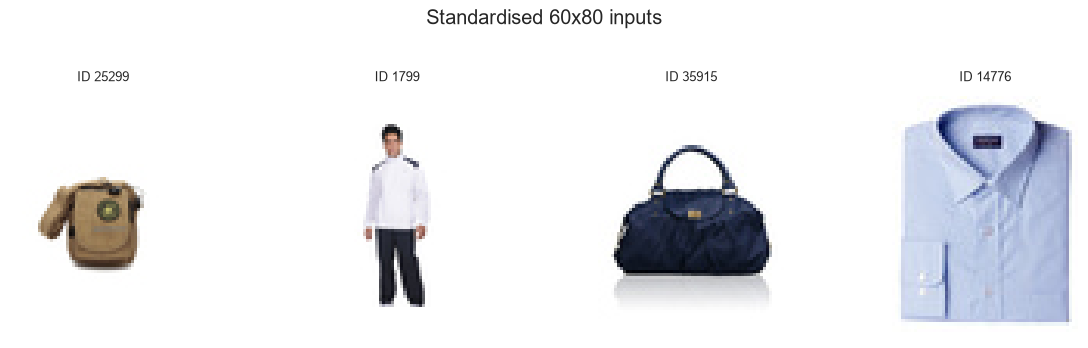

In [90]:
# Default: the catalogue's own modal size, so most images pass through unresized.
# Experiment later by overriding this one constant, e.g. IMAGE_TARGET_SIZE = (224, 224).
NATIVE_IMAGE_SIZE = tuple(int(v) for v in dimension_counts.index[0])  # (width, height)
IMAGE_TARGET_SIZE = NATIVE_IMAGE_SIZE
IMAGE_PAD_RGB = (255, 255, 255)

native_share = dimension_counts.iloc[0] / dimension_counts.sum() * 100
print(f"Native size {NATIVE_IMAGE_SIZE[0]}x{NATIVE_IMAGE_SIZE[1]} covers "
      f"{dimension_counts.iloc[0]:,} images ({native_share:.2f}%); "
      f"{int(dimension_counts.iloc[1:].sum()):,} images need resizing.")


def standardize_image(image, target_size=IMAGE_TARGET_SIZE):
    """Deterministic Task 1-4 input transform. Augmentation goes after this, normalisation last."""
    image = ImageOps.exif_transpose(image).convert("RGB")
    if image.size == tuple(target_size):
        return image  # already the target size: no resampling at all
    return ImageOps.pad(
        image, target_size, method=Image.Resampling.BILINEAR,
        color=IMAGE_PAD_RGB, centering=(0.5, 0.5),
    )


# Verify the transform against every observed source dimension and one grayscale file.
check_ids = readable_audit.groupby(["width", "height"], sort=True)["id"].first().tolist()
grayscale_ids = readable_audit.loc[readable_audit["is_grayscale"], "id"]
if len(grayscale_ids):
    check_ids.append(int(grayscale_ids.iloc[0]))

path_by_id = readable_audit.set_index("id")["path"]
for check_id in dict.fromkeys(map(int, check_ids)):
    with Image.open(path_by_id.loc[check_id]) as image:
        standardized = standardize_image(image)
    assert standardized.size == IMAGE_TARGET_SIZE and standardized.mode == "RGB"
print(f"Transform verified at {IMAGE_TARGET_SIZE} on {len(set(check_ids))} images "
      f"covering every observed size and colour mode.")

sample_ids = list(dict.fromkeys(map(int, check_ids)))[:4]
fig, axes = plt.subplots(1, len(sample_ids), figsize=(3 * len(sample_ids), 3.4))
for ax, sample_id in zip(np.atleast_1d(axes), sample_ids):
    with Image.open(path_by_id.loc[sample_id]) as image:
        ax.imshow(standardize_image(image))
    ax.set_title(f"ID {sample_id}", fontsize=9)
    ax.axis("off")
plt.suptitle(f"Standardised {IMAGE_TARGET_SIZE[0]}x{IMAGE_TARGET_SIZE[1]} inputs", y=1.02)
plt.tight_layout(); plt.show()

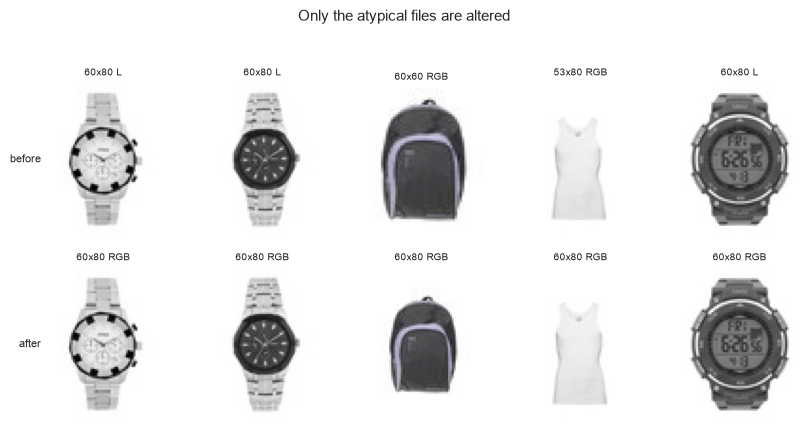

In [91]:
# Before and after, on the files the transform actually has to change.
awkward = pd.concat([odd_sized, grayscale_files]).drop_duplicates("id")
before_after = sample_paths(awkward, 5, seed_offset=4)
if before_after:
    fig, axes = plt.subplots(2, len(before_after), figsize=(1.7 * len(before_after), 4.2), squeeze=False)
    for column, record in enumerate(before_after):
        with Image.open(record.path) as image:
            original = ImageOps.exif_transpose(image).convert("RGB")
            transformed = standardize_image(image)
        for row_index, (picture, caption) in enumerate(
            [(original, f"{original.size[0]}x{original.size[1]} {record.mode}"),
             (transformed, f"{transformed.size[0]}x{transformed.size[1]} RGB")]
        ):
            ax = axes[row_index][column]
            ax.imshow(picture)
            ax.set_title(caption, fontsize=7)
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            for spine in ax.spines.values():
                spine.set_visible(False)
    axes[0][0].set_ylabel("before", fontsize=8, rotation=0, ha="right", va="center")
    axes[1][0].set_ylabel("after", fontsize=8, rotation=0, ha="right", va="center")
    fig.suptitle("Only the atypical files are altered", y=1.02, fontsize=11)
    plt.tight_layout(); plt.show()

## 3.2 Handle duplicated images

### 3.2.1 Remove fully consistent duplicates

In 636 byte-identical groups, 616 have no conflicting target values (615 are complete; one pair has `usage` missing in both rows). They are repeated image-label pairs, so one deterministic representative (the smallest `id`) is retained per group.

In [108]:
# Collapse only duplicate groups whose available target labels do not conflict.
# Conflicting groups remain unchanged for the task-specific decisions below.
consistent_label_hashes = group_labels.index[group_labels.le(1).all(axis=1)]
shared_missing_label_hashes = consistent_label_hashes[
    group_labels.loc[consistent_label_hashes].eq(0).any(axis=1)
]
consistent_group_sizes = (
    model_ready.loc[model_ready["group_id"].isin(consistent_label_hashes)]
    .groupby("group_id")
    .size()
)

consistent_duplicate_summary = pd.DataFrame([
    ["Groups with no label conflict", len(consistent_label_hashes)],
    ["Consistent groups with a shared missing label", len(shared_missing_label_hashes)],
    ["Images in groups with no label conflict", int(consistent_group_sizes.sum())],
], columns=["Measure", "Count"])

display(consistent_duplicate_summary)

,Measure,Count
0,Groups with no label conflict,616
1,Consistent groups with a shared missing label,1
2,Images in groups with no label conflict,1358


In [109]:
representative_ids = set(
    model_ready.loc[model_ready["group_id"].isin(consistent_label_hashes), ["group_id", "id"]]
    .sort_values(["group_id", "id"])
    .drop_duplicates("group_id", keep="first")["id"]
)

deduplicated_model_ready = (
    model_ready.loc[
        ~model_ready["group_id"].isin(consistent_label_hashes)
        | model_ready["id"].isin(representative_ids)
    ]
    .copy()
    .reset_index(drop=True)
)

display(deduplicated_model_ready.info())

<class 'pandas.DataFrame'>
RangeIndex: 37870 entries, 0 to 37869
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  37870 non-null  int64
 1   gender              37870 non-null  str  
 2   masterCategory      37870 non-null  str  
 3   subCategory         37870 non-null  str  
 4   articleType         37870 non-null  str  
 5   baseColour          37857 non-null  str  
 6   season              37850 non-null  str  
 7   year                37870 non-null  int64
 8   usage               37799 non-null  str  
 9   productDisplayName  37863 non-null  str  
 10  filename            37870 non-null  str  
 11  path                37870 non-null  str  
 12  group_id            37870 non-null  str  
dtypes: int64(2), str(11)
memory usage: 3.8 MB


None

### 3.2.2 Resolve Conflicting Labels in Images

The 20 exact-duplicate groups with conflicting metadata are reviewed through the audit table below. `model_ready` and the raw catalogue remain intact; the documented decisions are applied to task-specific working frames created from `deduplicated_model_ready`.

In [110]:
# Map byte-identical groups whose labels still conflict after clean duplicates
# have been collapsed. Conflict groups are intentionally unchanged in the base.
conflict_flags = group_labels.gt(1).rename(
    columns={target: f"{target}_conflict" for target in TARGETS}
)

conflicting_image_metadata = (
    deduplicated_model_ready.loc[
        deduplicated_model_ready["group_id"].isin(conflicting_hashes),
        ["group_id", "id", "filename", "productDisplayName", *TARGETS],
    ]
    .rename(columns={"group_id": "sha256"})
    .merge(
        conflict_flags,
        left_on="sha256",
        right_index=True,
        how="left",
        validate="many_to_one",
    )
)

conflicting_image_metadata["conflicting_fields"] = (
    conflicting_image_metadata[conflict_flags.columns]
    .apply(
        lambda row: ", ".join(
            column.removesuffix("_conflict")
            for column, is_conflict in row.items()
            if is_conflict
        ),
        axis=1,
    )
)

conflicting_image_metadata["duplicate_group_size"] = (
    conflicting_image_metadata.groupby("sha256")["id"].transform("size")
)

conflicting_image_metadata = (
    conflicting_image_metadata[
        [
            "sha256",
            "duplicate_group_size",
            "conflicting_fields",
            "id",
            "filename",
            "productDisplayName",
            *TARGETS,
        ]
    ]
    .sort_values(["sha256", "id"])
    .reset_index(drop=True)
)

display(conflicting_image_metadata)

,sha256,duplicate_group_size,conflicting_fields,id,filename,productDisplayName,articleType,season,gender,usage
0,101c50e6458d7ef48893fa3d7b464167589d23e0bdef6e9335351d582df6e268,2,gender,39107,39107.jpg,ADIDAS Mumbai Indians Boys Blue Match Cap,Caps,Summer,Boys,Sports
1,101c50e6458d7ef48893fa3d7b464167589d23e0bdef6e9335351d582df6e268,2,gender,39108,39108.jpg,ADIDAS Mumbai Indians Girls Blue Match Cap,Caps,Summer,Girls,Sports
2,10ee6d9aaa238c17a8eb0d3f21bd1e83afde3f9d48f8c7081d4e83b0aeb633fc,2,season,7158,7158.jpg,Scullers Men Green Check Shirt,Shirts,Fall,Men,Casual
3,10ee6d9aaa238c17a8eb0d3f21bd1e83afde3f9d48f8c7081d4e83b0aeb633fc,2,season,8786,8786.jpg,Scullers Men Blue & Green Check Shirt,Shirts,Summer,Men,Casual
4,1469f29721659fff4624704c271b1bf88f7e4de11ada94113c6b9cddfd46be2f,2,gender,36762,36762.jpg,Maxima Men White Dial Watch,Watches,Winter,Men,Casual
5,1469f29721659fff4624704c271b1bf88f7e4de11ada94113c6b9cddfd46be2f,2,gender,36771,36771.jpg,Maxima Women White Dial Watch,Watches,Winter,Women,Casual
6,261a589e0ad8167a6953a5a7849a4657a3523a982304ea21c989b107aa347f02,2,season,11346,11346.jpg,Lee Men Blue Zed Fit Jeans,Jeans,Spring,Men,Casual
7,261a589e0ad8167a6953a5a7849a4657a3523a982304ea21c989b107aa347f02,2,season,11347,11347.jpg,Lee Men Elvira Rinse Blue Chicago Fit Jeans,Jeans,Summer,Men,Casual
8,29b6d48fdf58b0b5917cc3c6338baa6fe4a72c560d1a309bd288049bb800c823,2,gender,13306,13306.jpg,Gini and Jony Kids Solid Black Trousers,Trousers,Fall,Boys,Casual
9,29b6d48fdf58b0b5917cc3c6338baa6fe4a72c560d1a309bd288049bb800c823,2,gender,13307,13307.jpg,Gini and Jony Kids Solid Black Trousers,Trousers,Fall,Men,Casual


**What was discovered?**

The audit table contains 20 exact-duplicate groups with at least one conflicting target.

- **Article type (7 groups):** **4** conflicts include Sunglasses/Free Gifts, Shorts/Capris, Tops/Tshirts, Free Gifts/Sarees, and the **3** multi-label groups.
- **Season (8 groups):** **5** season-only groups and **3** multi-label groups conflict. Season is weakly visible, so `productDisplayName` is supporting evidence; socks `18580`/`18592` remain ambiguous.
- **Gender (7 groups):** **7** conflicts span `Boys`/`Girls`, `Men`/`Women`, `Boys`/`Men`, and `Men`/`Unisex`; names and visual review provide a defensible retained label.
- **Usage (3 groups):** **1** Casual/Formal pair (`27559`/`43410`) and two multi-label groups conflict.
- **Multiple labels (3 groups):** `21810`/`23810`, `1165`/`5062`, and `12345`/`12346` disagree on article type plus one or more additional targets.

**Decision**

- **Article type:** retain `28345` as `Sunglasses`, `33259` as `Shorts`, and `51101` as `Sarees`; exclude `28347`, `39336`, and `51073`. Exclude `4898`/`4899` because the shared name does not distinguish `Tops` from `Tshirts`.
- **Season:** retain `7158` as `Fall`, `11347` and `37151` as `Summer`, and `2640` as `Winter`; exclude their counterparts. Exclude both socks `18580`/`18592` from season training.
- **Gender:** retain `39107` and `36762` as `Unisex`; retain `13306` and `8325` as `Boys`, `28167` and `30566` as `Men`, and `23793` as `Unisex`. Exclude the other records from gender training.
- **Usage:** exclude `27559`/`43410` because the shared product name does not distinguish `Casual` from `Formal`.
- **Multiple labels:** retain `23810` as `Casual Shoes`, `Fall`, and `Casual`; exclude `21810`. Exclude `1165`/`5062` and `12345`/`12346`.

In [120]:
# Start from the globally deduplicated base, then apply only the
# documented decisions for conflicting groups to task-specific frames.

def drop_id(data: pd.DataFrame, record_id: int):
    """Return a task frame without one catalogue record."""
    return data.loc[data["id"].ne(record_id)].copy()


def update_id(data: pd.DataFrame, record_id: int, values: dict):
    """Return a task frame with documented values applied to one record."""
    unknown_columns = set(values).difference(data.columns)
    if unknown_columns:
        raise KeyError(f"Unknown update columns: {sorted(unknown_columns)}")

    updated = data.copy()
    mask = updated["id"].eq(record_id)
    if mask.sum() != 1:
        raise ValueError(f"Expected one row for ID {record_id}, found {mask.sum()}")

    for column, value in values.items():
        updated.loc[mask, column] = value

    return updated


# Article-type decisions.
for record_id in [28347, 39336, 51073, 4898, 4899]:
    deduplicated_model_ready = drop_id(deduplicated_model_ready, record_id)

# Season decisions.
for record_id in [8786, 11346, 19110, 2638, 18580, 18592]:
    deduplicated_model_ready = drop_id(deduplicated_model_ready, record_id)

# Gender: update the two retained records whose label changes, then
# remove only the counterparts named in the decision.
deduplicated_model_ready = update_id(deduplicated_model_ready, 39107, {"gender": "Unisex"})
deduplicated_model_ready = update_id(deduplicated_model_ready, 36762, {"gender": "Unisex"})
for record_id in [39108, 36771, 13307, 8273, 30568, 28186, 28188, 24301]:
    deduplicated_model_ready = drop_id(deduplicated_model_ready, record_id)

# Usage decisions.
for record_id in [27559, 43410]:
    deduplicated_model_ready = drop_id(deduplicated_model_ready, record_id)

# Multi-label decisions (temporarily use article_type_data as all multi-label-conflicting data have articleType included).
for record_id in [21810, 1165, 5062, 12345, 12346]:
    deduplicated_model_ready = drop_id(deduplicated_model_ready, record_id)

display(deduplicated_model_ready.info())

<class 'pandas.DataFrame'>
Index: 37844 entries, 0 to 37869
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  37844 non-null  int64
 1   gender              37844 non-null  str  
 2   masterCategory      37844 non-null  str  
 3   subCategory         37844 non-null  str  
 4   articleType         37844 non-null  str  
 5   baseColour          37831 non-null  str  
 6   season              37824 non-null  str  
 7   year                37844 non-null  int64
 8   usage               37773 non-null  str  
 9   productDisplayName  37837 non-null  str  
 10  filename            37844 non-null  str  
 11  path                37844 non-null  str  
 12  group_id            37844 non-null  str  
dtypes: int64(2), str(11)
memory usage: 4.0 MB


None

## 3.3 Drop rows with any null values

In [123]:
deduplicated_model_ready = deduplicated_model_ready.dropna()

display(deduplicated_model_ready.info())

<class 'pandas.DataFrame'>
Index: 37745 entries, 0 to 37869
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  37745 non-null  int64
 1   gender              37745 non-null  str  
 2   masterCategory      37745 non-null  str  
 3   subCategory         37745 non-null  str  
 4   articleType         37745 non-null  str  
 5   baseColour          37745 non-null  str  
 6   season              37745 non-null  str  
 7   year                37745 non-null  int64
 8   usage               37745 non-null  str  
 9   productDisplayName  37745 non-null  str  
 10  filename            37745 non-null  str  
 11  path                37745 non-null  str  
 12  group_id            37745 non-null  str  
dtypes: int64(2), str(11)
memory usage: 4.0 MB


None

## 3.4 Save preprocessed data to disk

In [124]:
from shutil import copy2

EXPORT_TRAIN_DIR = PROJECT_ROOT / "preprocessed_datasets" / "train"
EXPORT_IMAGE_DIR = EXPORT_TRAIN_DIR / "images_train"
EXPORT_CSV = EXPORT_TRAIN_DIR / "styles_train.csv"
EXPORT_HELPER_COLUMNS = ["filename", "path", "group_id"]

export_rows = deduplicated_model_ready.sort_values("id").reset_index(drop=True).copy()

EXPORT_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
for row in export_rows[["filename", "path"]].itertuples(index=False):
    copy2(row.path, EXPORT_IMAGE_DIR / row.filename)

export_metadata = export_rows.drop(columns=EXPORT_HELPER_COLUMNS)
export_metadata.to_csv(EXPORT_CSV, index=False, encoding="utf-8")

saved_files = list(EXPORT_IMAGE_DIR.iterdir())

print(f"Saved CSV: {EXPORT_CSV}")
print(f"Saved raw images: {len(saved_files):,} files in {EXPORT_IMAGE_DIR}")

Saved CSV: C:\Users\NguyenKhang\Documents\Machine-Learning-Assignment-2\preprocessed_datasets\train\styles_train.csv
Saved raw images: 37,745 files in C:\Users\NguyenKhang\Documents\Machine-Learning-Assignment-2\preprocessed_datasets\train\images_train


## 3.5 How Should the Data Be Split?

**Why the split is not performed here.**

- The four targets have different valid rows, cleaned labels, class distributions, and rare-class constraints.
- One global split may suit one target but give another a poor training or validation distribution.
- A shared split could also apply a Section 3.2 exclusion to tasks for which that row remains valid.
- Each task therefore builds the split that best matches its own eligible population.

**Shared splitting approach.**

- Use an approximately 80:20 hold-out split for each task's eligible rows.
- Stratify where class support permits so supported classes remain representative in both sets.
- Keep singleton classes in training because their only example cannot also be evaluated.
- Keep every `group_id` in one set to prevent exact-image leakage; the final ratio may therefore differ slightly from 80:20.



---

# Everything below is task-specific

Tasks 1–4 continue from here. Each task section is self-contained apart from two shared objects defined above: `model_ready` and `standardize_image()`.

Two rules every task section must follow, both of them consequences of findings above:

1. Build its split with `group_id` as the grouping key (§1.6), so byte-identical images cannot appear on both sides.
2. Fit normalisation constants, scalers, and other task-specific preprocessing values on the appropriate task data, then apply them unchanged to validation.

`IMAGE_TARGET_SIZE` is the one knob deliberately left open: the default keeps images at their native resolution, and any task section may rerun itself at a larger size to test whether the extra pixels pay for themselves.